<a href="https://colab.research.google.com/github/gshaurya27/LS-Intro-to-ML-Assignments/blob/main/WEEK%202/Week%202%20Assignment%20-%20IMDb%20Sentiment%20Analyser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
# ========== SETUP ==========
# Run this cell first - it installs dependencies and downloads the dataset

!pip install datasets -q

import numpy as np
import matplotlib.pyplot as plt
import re
import math
from collections import Counter, defaultdict
from datasets import load_dataset

# Load IMDb dataset
print('Loading IMDb dataset...')
dataset = load_dataset('stanfordnlp/imdb', trust_remote_code=True)

# Use a subset for speed
N_TRAIN = 5000
N_TEST  = 1000

# Shuffle and select subsets before extracting lists
train_subset = dataset['train'].shuffle(seed=42).select(range(N_TRAIN))
test_subset  = dataset['test'].shuffle(seed=42).select(range(N_TEST))

# Extract texts and labels
train_texts  = train_subset['text']
train_labels = train_subset['label']
test_texts   = test_subset['text']
test_labels  = test_subset['label']

print(f'Loaded {N_TRAIN} training and {N_TEST} test reviews.')
print(f'Sample review: "{train_texts[0][:120]}..."')
print(f'Label: {"Positive" if train_labels[0] == 1 else "Negative"}')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'stanfordnlp/imdb' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'stanfordnlp/imdb' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading IMDb dataset...
Loaded 5000 training and 1000 test reviews.
Sample review: "There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. ..."
Label: Positive


In [46]:

STOPWORDS = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're",
    "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'he', 'him', 'his',
    'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its',
    'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which',
    'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do',
    'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because',
    'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against',
    'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below',
    'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
    'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how',
    'all', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'than',
    'too', 'very', 's', 't', 'can', 'will', 'just', 'should', "should've", 'now',
    'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn',
    "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn',
    "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't",
    'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn',
    "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn',
    "wouldn't"
])

def preprocess(text):
    """
    Clean and tokenise a raw review string.
    Returns a list of tokens (strings).
    """
    # Step 1: Lowercase
    text = text.lower()
    # Step 2: Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Step 3: Keep only letters and spaces (remove punctuation, numbers)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Step 4: Tokenise by splitting on whitespace
    tokens = text.split()
    # Step 5: Remove stopwords and very short tokens
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return tokens

# Preprocess all reviews
print('Preprocessing reviews...')
train_tokens = [preprocess(t) for t in train_texts]
test_tokens  = [preprocess(t) for t in test_texts]

print('Sample tokens:', train_tokens[0][:15])

Preprocessing reviews...
Sample tokens: ['relation', 'fortier', 'profiler', 'fact', 'police', 'series', 'violent', 'crimes', 'profiler', 'looks', 'crispy', 'fortier', 'looks', 'classic', 'profiler']


In [47]:
class BagOfWords:
    def __init__(self, max_vocab=5000):
        self.max_vocab = max_vocab
        self.vocab = {}       # word → index
        self.vocab_size = 0

    def fit(self, token_lists):
        """
        Build vocabulary from training data.
        Keep only the top `max_vocab` most frequent words.
        """
        # Count all word frequencies across all token_lists
        counter = Counter()
        for tokens in token_lists:
            counter.update(tokens)

        # Take the top max_vocab words
        most_common = counter.most_common(self.max_vocab)
        self.vocab = {word: idx for idx, (word, _) in enumerate(most_common)}
        self.vocab_size = len(self.vocab)
        print(f'Vocabulary built: {self.vocab_size} words')
        return self

    def transform(self, token_lists):
        """
        Convert a list of token lists into a count matrix.
        Output shape: (num_documents, vocab_size)
        """
        num_documents = len(token_lists)
        output = np.zeros((num_documents, self.vocab_size))
        for i, tokens in enumerate(token_lists):
            for token in tokens:
                if token in self.vocab:
                    output[i, self.vocab[token]] += 1
        return output

    def fit_transform(self, token_lists):
        return self.fit(token_lists).transform(token_lists)


bow = BagOfWords(max_vocab=5000)
X_train_bow = bow.fit_transform(train_tokens)
X_test_bow  = bow.transform(test_tokens)
y_train = np.array(train_labels)
y_test  = np.array(test_labels)

print(f'X_train_bow shape: {X_train_bow.shape}')  # (5000, 5000)
print(f'Sparsity: {(X_train_bow == 0).mean():.1%} zeros')


Vocabulary built: 5000 words
X_train_bow shape: (5000, 5000)
Sparsity: 98.4% zeros


In [48]:
class TFIDF:
    def __init__(self, max_vocab=5000):
        self.max_vocab = max_vocab
        self.vocab = {}
        self.idf = None

    def fit(self, token_lists):
        # Build vocab (same as BoW)
        counter = Counter()
        for tokens in token_lists:
            counter.update(tokens)
        most_common = counter.most_common(self.max_vocab)
        self.vocab = {word: idx for idx, (word, _) in enumerate(most_common)}

        # Compute IDF for each vocab word
        # IDF(word) = log((1 + N) / (1 + df(word))) + 1  [smoothed version]
        # where N = number of documents, df = number of docs containing the word
        N = len(token_lists)
        df = np.zeros(len(self.vocab), dtype=np.float32)

        for tokens in token_lists:
            unique_tokens = set(tokens)
            for word in unique_tokens:
                if word in self.vocab:
                    df[self.vocab[word]] += 1

        self.idf = np.log((1 + N) / (1 + df)) + 1
        print(f'TF-IDF vocab size: {len(self.vocab)}')
        return self

    def transform(self, token_lists):
        # YOUR CODE HERE
        # Step 1: Compute TF matrix (normalised count per document)
        num_documents = len(token_lists)
        tf = np.zeros((num_documents, len(self.vocab)))
        for i, tokens in enumerate(token_lists):
            counter = Counter(tokens)
            for token, count in counter.items():
                if token in self.vocab:
                    tf[i, self.vocab[token]] = count / len(tokens)

        # Step 2: Multiply elementwise by IDF weights
        tfidf = tf * self.idf

        # Step 3: L2-normalise each row
        norm = np.zeros((num_documents, 1))
        for i in range(num_documents):
            for n in range(len(self.vocab)):
                norm[i] += (tfidf[i, n]) ** 2
        norm = np.sqrt(norm)
        tfidf = tfidf / norm
        return tfidf

    def fit_transform(self, token_lists):
        return self.fit(token_lists).transform(token_lists)


tfidf = TFIDF(max_vocab=5000)
X_train_tfidf = tfidf.fit_transform(train_tokens)
X_test_tfidf  = tfidf.transform(test_tokens)

print(f'X_train_tfidf shape: {X_train_tfidf.shape}')



TF-IDF vocab size: 5000
X_train_tfidf shape: (5000, 5000)


In [49]:
def confusion_matrix(y_true, y_pred):
    """Returns [[TN, FP], [FN, TP]] for binary classification."""
    TN = FP = FN = TP = 0
    for yp, yt in zip(y_pred, y_true):
        if yp ==0 and yt == 0:
            TN += 1
        elif yp == 1 and yt == 0:
            FP += 1
        elif yp == 0 and yt == 1:
            FN += 1
        elif yp == 1 and yt == 1:
            TP += 1
    return np.array([[TN, FP],[FN, TP]])

def accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return (cm[0,0] + cm[1,1]) / cm.sum()

def precision(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm[1,1] / (cm[0,1] + cm[1,1])

def recall(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm[1,1] / (cm[1,0] + cm[1,1])

def f1_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * (p * r) / (p + r)

def plot_confusion_matrix(cm, title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Neg (pred)', 'Pos (pred)'])
    ax.set_yticklabels(['Neg (true)', 'Pos (true)'])
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{labels[i][j]}\n{cm[i,j]}',
                    ha='center', va='center', fontsize=13,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax.set_title(title, fontsize=14, pad=12)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

def evaluate(y_true, y_pred, name='Model'):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy(y_true, y_pred)
    p   = precision(y_true, y_pred)
    r   = recall(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    print(f'\n===== {name} =====')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {p:.4f}')
    print(f'Recall   : {r:.4f}')
    print(f'F1 Score : {f1:.4f}')
    plot_confusion_matrix(cm, title=name)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

print('Evaluation toolkit ready!')


Evaluation toolkit ready!


Training Logistic Regression baseline...

===== Logistic Regression (TF-IDF Baseline) =====
Accuracy : 0.8480
Precision: 0.8243
Recall   : 0.8750
F1 Score : 0.8489


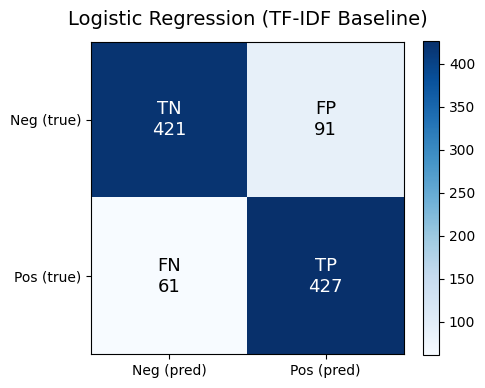

In [51]:
from sklearn.linear_model import LogisticRegression

print('Training Logistic Regression baseline...')
lr = LogisticRegression(max_iter=1000, C=1.0)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
lr_metrics = evaluate(y_test, y_pred_lr, name='Logistic Regression (TF-IDF Baseline)')

In [53]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Convert numpy arrays to PyTorch tensors
X_tr = torch.tensor(X_train_tfidf, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.long)
X_te = torch.tensor(X_test_tfidf, dtype=torch.float32)
y_te = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_tr, y_tr)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

# ===== Define the MLP =====
class SentimentMLP(nn.Module):
    def __init__(self, input_dim, hidden1=256, hidden2=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model     = SentimentMLP(input_dim=5000)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal trainable parameters: {total_params:,}')

SentimentMLP(
  (net): Sequential(
    (0): Linear(in_features=5000, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

Total trainable parameters: 1,313,410


Epoch 01/15  Loss: 0.4853  Train Acc: 0.7788
Epoch 02/15  Loss: 0.1533  Train Acc: 0.9424
Epoch 03/15  Loss: 0.0503  Train Acc: 0.9896
Epoch 04/15  Loss: 0.0155  Train Acc: 0.9978
Epoch 05/15  Loss: 0.0044  Train Acc: 0.9996
Epoch 06/15  Loss: 0.0013  Train Acc: 1.0000
Epoch 07/15  Loss: 0.0005  Train Acc: 1.0000
Epoch 08/15  Loss: 0.0002  Train Acc: 1.0000
Epoch 09/15  Loss: 0.0001  Train Acc: 1.0000
Epoch 10/15  Loss: 0.0000  Train Acc: 1.0000
Epoch 11/15  Loss: 0.0000  Train Acc: 1.0000
Epoch 12/15  Loss: 0.0000  Train Acc: 1.0000
Epoch 13/15  Loss: 0.0000  Train Acc: 1.0000
Epoch 14/15  Loss: 0.0000  Train Acc: 1.0000
Epoch 15/15  Loss: 0.0000  Train Acc: 1.0000


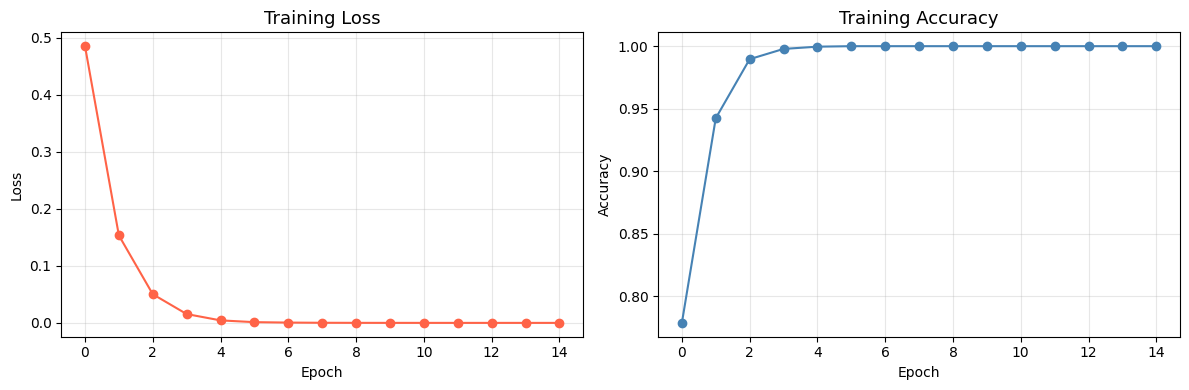

In [54]:
# ===== Training Loop =====
EPOCHS = 15
train_losses = []
train_accs   = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(y_batch)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)

    avg_loss = epoch_loss / total
    avg_acc  = correct / total
    train_losses.append(avg_loss)
    train_accs.append(avg_acc)
    print(f'Epoch {epoch+1:02d}/{EPOCHS}  Loss: {avg_loss:.4f}  Train Acc: {avg_acc:.4f}')

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, marker='o', color='tomato')
ax1.set_title('Training Loss', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, marker='o', color='steelblue')
ax2.set_title('Training Accuracy', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


===== MLP (TF-IDF Input) =====
Accuracy : 0.8280
Precision: 0.8238
Recall   : 0.8238
F1 Score : 0.8238


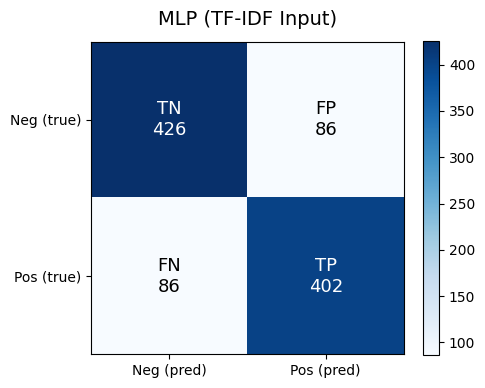

In [55]:
# ===== Evaluate MLP on Test Set =====
model.eval()
with torch.no_grad():
    logits = model(X_te)
    y_pred_mlp = logits.argmax(dim=1).numpy()

mlp_metrics = evaluate(y_test, y_pred_mlp, name='MLP (TF-IDF Input)')

In [56]:

# ===== Sanity Check =====
print('========== SANITY CHECK ==========')
print(f'Logistic Regression F1: {lr_metrics["f1"]:.4f}')
print(f'MLP F1:                 {mlp_metrics["f1"]:.4f}')

if mlp_metrics['f1'] > 0.70:
    print('✅ PASS: MLP F1 > 0.70')
else:
    print('❌ MLP F1 is below 0.70. Try training for more epochs, tuning hidden sizes, or adjusting learning rate.')

# Quick demo
print('\n===== DEMO =====')
demo_reviews = [
    'This movie was absolutely brilliant. The acting was superb and the story was moving.',
    'Terrible film. Boring, predictable, and a complete waste of time.'
]
for rev in demo_reviews:
    tokens  = preprocess(rev)
    vec     = tfidf.transform([tokens])
    x_demo  = torch.tensor(vec, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        logit  = model(x_demo)
        prob   = torch.softmax(logit, dim=1)
        pred   = prob.argmax().item()
    label = '😊 Positive' if pred == 1 else '😞 Negative'
    conf  = prob[0, pred].item()
    print(f'  Review: "{rev[:60]}..."')
    print(f'  → Prediction: {label}  (confidence: {conf:.2%})\n')

========== SANITY CHECK ==========
Logistic Regression F1: 0.8489
MLP F1:                 0.8238
✅ PASS: MLP F1 > 0.70

===== DEMO =====
  Review: "This movie was absolutely brilliant. The acting was superb a..."
  → Prediction: 😊 Positive  (confidence: 100.00%)

  Review: "Terrible film. Boring, predictable, and a complete waste of ..."
  → Prediction: 😞 Negative  (confidence: 100.00%)



# Part 7 - Reflection (Required)


---


---



**What was the F1 score of your Logistic Regression baseline?**

Logistic Regression F1: 0.8489


---


**What was the F1 score of your MLP?**

MLP F1 : 0.8238


---


**Did the MLP outperform the baseline? By how much? Why do you think that is?**

No, the MLP didn't out perform the LR baseline. LR baseline'F1 was 2.5% greater than MLP'F1.

I think it happened beacuse of small dataset, and MLP may have overfit the training data that's why its accuracy reached to a 100%. Logistic Regression works very well with TF-IDF features and was able to generalize better on the test set.

---

**Look at your confusion matrix. Where does your model make the most mistakes - false positives or false negatives? What kind of reviews do you think it gets wrong?**

By looking at the confusion matrix we can say that my model makes the most mistakes in guessing False Positives (i.e. it make a mistake while guessing that a particular review is positive but actually it is negative).
I think it fails for reviews which contain sarcasm, mixed opinion or complex phrases, because TF-IDF only concentrates its focus on individual words and not the whole context of the sentence.

---

**The model is still using TF-IDF as input. What is the fundamental limitation here? What would need to change to build a truly "understanding" model?**


The limitation of using TI-IDF is that it focuses on individual words rather than focusing on there context/meaning. It can't understand difference in meaning of the same word used in different phrases.
We would need to replace TI-IDF with learned word embeddings and contextual models such as neural networks based on transformers, which can capture semantic meaning and relationships between words.